In [53]:
#It`s me 𝓞𝓶𝓪𝓻

# NoteBook link :
[DigitaMart.ipynb](https://colab.research.google.com/drive/1ywEvQ4_dQ9uOUhKwXQJxUsMDbRfPW7hJ?usp=sharing)

#DigitaMart Data Analysis Project

---

## Project Introduction

In this project, I will work as a data analyst for **DigitaMart**, an online store in Egypt. The goal is to inspect, clean, analyze, and visualize the store's order data using **Python**, **Pandas**, and **Matplotlib** in Google Colab.

The project begins by loading and exploring the dataset to understand its structure. Next, I will inspect the data, identify problems such as missing values, duplicate records, inconsistent city names, and outliers, then clean the dataset using appropriate data cleaning techniques.

After cleaning, I will analyze the data to answer important business questions, create clear visualizations, and summarize the key findings. Finally, I will provide practical recommendations that can help DigitaMart make better business decisions based on the analysis.


# Task 1 — Setup & `HEAD` Look







In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('digitamart_orders.csv')

df.head()

,order_id,order_date,city,product_category,product_name,order_total,delivery_minutes,customer_rating,payment_method,customer_age
0,1001,2024-11-23,Cairo,Electronics,USB-C Cable,425.15,26.0,5.0,Wallet,18.0
1,1002,2024-08-04,Cairo,Food & Groceries,Olive Oil 1L,232.62,137.0,4.0,Wallet,63.0
2,1003,2025-01-30,Giza,Food & Groceries,Spice Set,131.09,38.0,2.0,Credit Card,21.0
3,1004,2024-06-10,Giza,Clothing,Leather Belt,1609.73,55.0,3.0,Bank Transfer,26.0
4,1005,2024-01-25,Aswan,Electronics,Power Bank,4483.71,22.0,5.0,Wallet,150.0


**The** dataset was loaded successfully, and I used `df.head()` to show first 5 rows.

# Self learning task
Find out how many rows and how many columns the dataset has. The rows represent the number of orders, and the columns represent the information recorded about each order.

Also print out the names of every column, so that you know exactly what you are working with before you start.

In [55]:
print("Rows:", df.shape[0], " Columns:", df.shape[1])
print("\nColumn names:")
for c in df.columns:
    print(" >", c)

Rows: 326  Columns: 10

Column names:
 > order_id
 > order_date
 > city
 > product_category
 > product_name
 > order_total
 > delivery_minutes
 > customer_rating
 > payment_method
 > customer_age


### Describe the data

This dataset has **326 orders** from **DigitaMart** ( 326 row , 10 col ). Each row is one order. It includes city, product, order total, delivery time, rating, payment method, customer age, and order date.

order_total is numeric, city is categorical.

The data needs cleaning before analysis.

## Task 2 — Data Cleaning (1)
### Step 1: Inspect

In [56]:
print(df.dtypes)
df.info()
df.isna().sum()
print("Fully duplicated rows:", df.duplicated().sum())
df.describe()

order_id              int64
order_date           object
city                 object
product_category     object
product_name         object
order_total         float64
delivery_minutes    float64
customer_rating     float64
payment_method       object
customer_age        float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          326 non-null    int64  
 1   order_date        320 non-null    object 
 2   city              324 non-null    object 
 3   product_category  326 non-null    object 
 4   product_name      326 non-null    object 
 5   order_total       324 non-null    float64
 6   delivery_minutes  324 non-null    float64
 7   customer_rating   321 non-null    float64
 8   payment_method    326 non-null    object 
 9   customer_age      324 non-null    float64
dtypes: float64(4), int64(1), object(

,order_id,order_total,delivery_minutes,customer_rating,customer_age
count,326.000000,324.000000,324.000000,321.000000,324.000000
mean,1161.831288,910.664846,115.867284,3.096573,43.148148
std,92.661729,1041.342093,124.678997,1.396431,15.567777
min,1001.000000,-322.350000,22.000000,0.000000,18.000000
25%,1082.250000,228.695000,63.500000,2.000000,30.000000
50%,1162.500000,397.225000,105.000000,3.000000,45.000000
75%,1241.750000,1293.377500,139.250000,4.000000,55.250000
max,1320.000000,4483.710000,1181.000000,5.000000,150.000000


### Step 2: Problems Found

1. There are 6 duplicate rows and they should be removed.
2. City names are written in different ways (`Cairo`, `cairo`, `CAIRO`, `GIZA`), so they need to be unified.
3. Some columns have missing values like `order_date`, `city`, `order_total`, `delivery_minutes`, `customer_rating`, `and customer_age`.
4. Some `order_total` values are negative, which is not possible and should be fixed.
5. `customer_age` has an unrealistic value (150), and `delivery_minutes` has very large values that may be wrong.

### Step 3: Duplicates

#Self learning task :
Duplicates are repeated orders — the same order recorded more than once. Find these duplicates and remove them. Print the number of rows before and after, so the number of removed orders is visible.





In [57]:
before = len(df)
dupes = df[df.duplicated(subset=['order_id'], keep=False)]
print("Row count BEFORE:", before)
dupes[['order_id','order_date','city','order_total']]

Row count BEFORE: 326


,order_id,order_date,city,order_total
112,1113,2024-11-23,Giza,417.21
173,1174,2024-09-08,Giza,1447.33
239,1240,2024-09-13,Giza,93.41
259,1260,2024-11-27,Mansoura,73.37
300,1301,2024-06-09,Alexandria,138.09
308,1309,2024-07-21,Alexandria,376.31
320,1260,2024-11-27,Mansoura,73.37
321,1113,2024-11-23,Giza,417.21
322,1301,2024-06-09,Alexandria,138.09
323,1174,2024-09-08,Giza,1447.33


In [58]:
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print("Row count AFTER:", after)
print("Rows removed:", before - after)

Row count AFTER: 320
Rows removed: 6


### Step 4: City Names

In [59]:
print("BEFORE:", sorted(df['city'].dropna().unique()))

BEFORE: ['Alexandria', 'Aswan', 'CAIRO', 'Cairo', 'GIZA', 'Giza', 'Mansoura', 'alexandria', 'cairo', 'mansoura']


In [60]:
df['city'] = df['city'].str.strip().str.title()
vals = sorted(df['city'].dropna().unique())
print("AFTER:", vals)
print("Number of distinct cities:", len(vals))

AFTER: ['Alexandria', 'Aswan', 'Cairo', 'Giza', 'Mansoura']
Number of distinct cities: 5


Bonus: (payment_method) has the same casing problem, which would break the payment-method analysis in Task 3, so it's fixed here too.

In [61]:
print("payment_method BEFORE:", sorted(df['payment_method'].dropna().unique()))
df['payment_method'] = df['payment_method'].str.strip().str.title()
print("payment_method AFTER: ", sorted(df['payment_method'].dropna().unique()))

payment_method BEFORE: ['Bank Transfer', 'Cash', 'Credit Card', 'Wallet', 'bank transfer', 'cash', 'credit card', 'wallet']
payment_method AFTER:  ['Bank Transfer', 'Cash', 'Credit Card', 'Wallet']


## Task 2 — Data Cleaning
### Step 5: Missing Values

In [62]:
print(df.isna().sum())

order_id            0
order_date          6
city                2
product_category    0
product_name        0
order_total         2
delivery_minutes    2
customer_rating     5
payment_method      0
customer_age        2
dtype: int64


### Fill method & reasoning

- Rows with missing `city` and `order_date` were removed because they cannot be guessed.
- Negative `order_total` values were treated as errors and replaced with missing values.
- Missing values in `order_total`, `delivery_minutes`, `customer_rating`, and `customer_age` were filled using the median because it is not affected by outliers.

In [63]:
print("Rows before:", len(df))
df = df.dropna(subset=['city', 'order_date']).reset_index(drop=True)

# Negative order totals are impossible -> treat as missing, not valid
df.loc[df['order_total'] < 0, 'order_total'] = np.nan

for c in ['order_total', 'delivery_minutes', 'customer_rating', 'customer_age']:
    df[c] = df[c].fillna(df[c].median())

print(df.isna().sum())
print("Rows after:", len(df))

Rows before: 320
order_id            0
order_date          0
city                0
product_category    0
product_name        0
order_total         0
delivery_minutes    0
customer_rating     0
payment_method      0
customer_age        0
dtype: int64
Rows after: 312


### Step 6: Outliers (IQR method on order_total)

In [64]:
Q1 = df['order_total'].quantile(0.25)
Q3 = df['order_total'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Lower bound = {lower_bound:.2f}")
print(f"Upper bound = {upper_bound:.2f}")

outliers = ((df['order_total'] < lower_bound) |
            (df['order_total'] > upper_bound))

print("Outliers found:", outliers.sum())

df['order_total'] = df['order_total'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("After capping:")
df['order_total'].describe()

Q1 = 235.88
Q3 = 1312.21
IQR = 1076.33
Lower bound = -1378.61
Upper bound = 2926.70
Outliers found: 29
After capping:


,order_total
count,312.000000
mean,882.285657
std,903.939945
min,48.610000
25%,235.882500
50%,425.150000
75%,1312.207500
max,2926.695000


## Save Clean Data

The dataset is cleaned and ready to use.
I will save the cleaned version as a CSV file.





### Step 7: Save

In [65]:
#Finally saving csv
df.to_csv('digitamart_orders_clean.csv', index=False)
print("digitamart_orders_clean.csv")
print("Final shape:", df.shape)

digitamart_orders_clean.csv
Final shape: (312, 10)


# Testing the cleaned data

In [66]:
print("Cleaned Data:")
df.head()

Cleaned Data:


,order_id,order_date,city,product_category,product_name,order_total,delivery_minutes,customer_rating,payment_method,customer_age
0,1001,2024-11-23,Cairo,Electronics,USB-C Cable,425.150,26.0,5.0,Wallet,18.0
1,1002,2024-08-04,Cairo,Food & Groceries,Olive Oil 1L,232.620,137.0,4.0,Wallet,63.0
2,1003,2025-01-30,Giza,Food & Groceries,Spice Set,131.090,38.0,2.0,Credit Card,21.0
3,1004,2024-06-10,Giza,Clothing,Leather Belt,1609.730,55.0,3.0,Bank Transfer,26.0
4,1005,2024-01-25,Aswan,Electronics,Power Bank,2926.695,22.0,5.0,Wallet,150.0


In [67]:
df.describe()

,order_id,order_total,delivery_minutes,customer_rating,customer_age
count,312.000000,312.000000,312.000000,312.000000,312.000000
mean,1159.711538,882.285657,109.983974,3.096154,43.185897
std,92.745547,903.939945,104.291499,1.387954,15.573208
min,1001.000000,48.610000,22.000000,0.000000,18.000000
25%,1079.750000,235.882500,60.750000,2.000000,30.000000
50%,1159.500000,425.150000,104.000000,3.000000,45.000000
75%,1240.250000,1312.207500,138.000000,4.000000,55.250000
max,1320.000000,2926.695000,1181.000000,5.000000,150.000000


In [68]:
df.isna().sum()

,0
order_id,0
order_date,0
city,0
product_category,0
product_name,0
order_total,0
delivery_minutes,0
customer_rating,0
payment_method,0
customer_age,0


In [69]:
df.dtypes

,0
order_id,int64
order_date,object
city,object
product_category,object
product_name,object
order_total,float64
delivery_minutes,float64
customer_rating,float64
payment_method,object
customer_age,float64


In [70]:
df.duplicated().sum()

np.int64(0)

## Task 3 — Analysis with pandas & matplotlib

In [71]:
print("Shape:", df.shape)
df.describe()

Shape: (312, 10)


,order_id,order_total,delivery_minutes,customer_rating,customer_age
count,312.000000,312.000000,312.000000,312.000000,312.000000
mean,1159.711538,882.285657,109.983974,3.096154,43.185897
std,92.745547,903.939945,104.291499,1.387954,15.573208
min,1001.000000,48.610000,22.000000,0.000000,18.000000
25%,1079.750000,235.882500,60.750000,2.000000,30.000000
50%,1159.500000,425.150000,104.000000,3.000000,45.000000
75%,1240.250000,1312.207500,138.000000,4.000000,55.250000
max,1320.000000,2926.695000,1181.000000,5.000000,150.000000


**Goals:**
1. Which city generates the most total revenue?
2. Is there a relationship between order value and delivery time?
3. How are orders split across payment methods?

In [72]:
rev_by_city = df.groupby('city')['order_total'].sum()

print(rev_by_city)

print("\nCity with highest revenue:", rev_by_city.idxmax())
print("Revenue:", rev_by_city.max())

city
Alexandria    44383.315
Aswan         69440.690
Cairo         61416.905
Giza          55969.775
Mansoura      44062.440
Name: order_total, dtype: float64

City with highest revenue: Aswan
Revenue: 69440.69


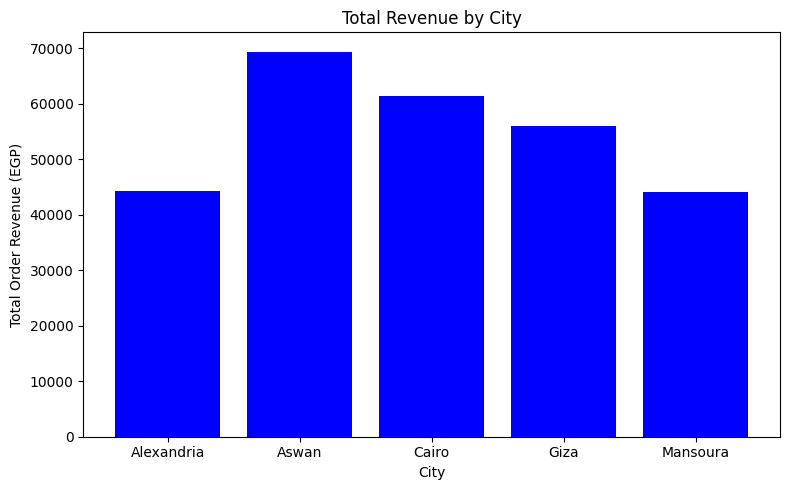

In [73]:
plt.figure(figsize=(8,5))
plt.bar(rev_by_city.index, rev_by_city.values, color='blue')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Order Revenue (EGP)')
plt.tight_layout()
plt.show()

In [74]:
corr_val = df['order_total'].corr(df['delivery_minutes'])
print(f"Correlation (order_total vs delivery_minutes): r = {corr_val:}")

Correlation (order_total vs delivery_minutes): r = 0.032439582449034166


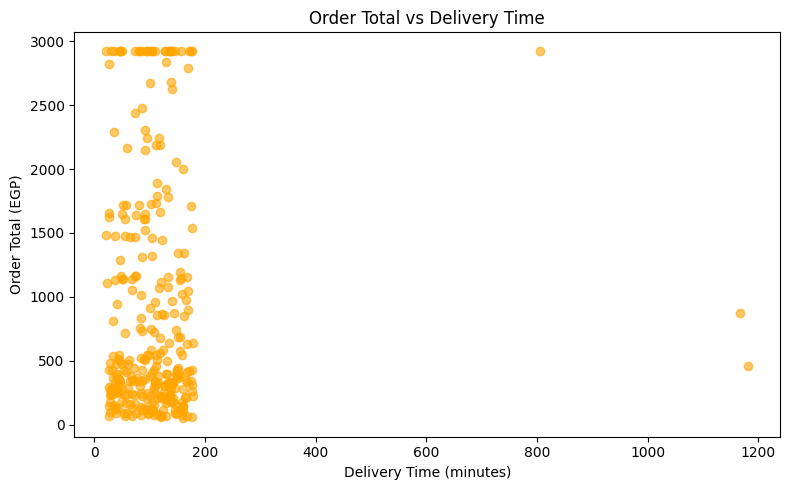

In [75]:
plt.figure(figsize=(8,5))
plt.scatter(df['delivery_minutes'], df['order_total'], alpha=0.6, color='orange')
plt.title('Order Total vs Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Order Total (EGP)')
plt.tight_layout()
plt.show()

In [76]:
pay_share = (df['payment_method'].value_counts() / len(df)) * 100

print(pay_share.round(1))

payment_method
Bank Transfer    27.2
Wallet           24.7
Credit Card      24.0
Cash             24.0
Name: count, dtype: float64


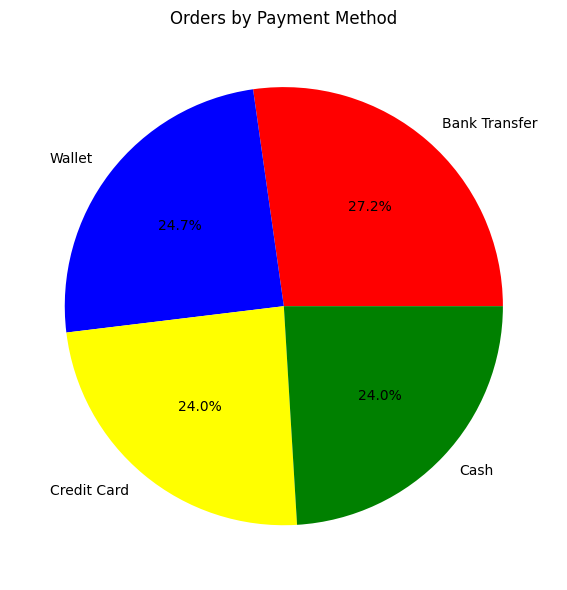

In [77]:
plt.figure(figsize=(6,6))
plt.pie(pay_share.values, labels=pay_share.index, autopct='%1.1f%%',
        colors=['red','blue','yellow','green'])
plt.title('Orders by Payment Method')

plt.tight_layout()
plt.show()

**Summary:**

The analysis shows that **Aswan** has the highest total revenue, while **Mansoura** has the lowest. There is almost no relationship between delivery time and order value, which means customers do not spend more because of faster delivery. The payment methods are used in similar percentages, so all of them are important and should continue to be supported. It would also be useful to understand why Aswan has the highest revenue and see if the same approach can improve sales in other cities.

## Task 4 — Insights & Hypotheses

### Insights

**Insight 1**

Aswan has the highest total revenue, while Mansoura has the lowest. This means Aswan is performing better than the other cities. It would be useful to know why and try the same idea in other cities.

**Hypothesis 1**

Maybe Aswan has more orders or more expensive orders.

---

**Insight 2**

Delivery time has almost no effect on the order value. The correlation is only **0.03**, which is very close to zero.

**Hypothesis 2**

Maybe delivery time affects customer ratings instead of how much they spend.

### Final Submission

The notebook is complete with data cleaning, analysis, charts, insights, and hypotheses. The only remaining steps are to run the notebook to make sure there are no errors




In [78]:
print("It was me (Omar Abd Elrahim)\nThanks for reading")


It was me (Omar Abd Elrahim)
Thanks for reading
